# IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
# DATA LOADING
dollarrss = pd.read_csv("exchange_rate.csv", index_col="date", parse_dates=True)


In [3]:
# Display the full DataFrame — confirms shape, index type, and Ex_rate values.
dollarrss

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [4]:
# DATE FORMAT PARSING
dollarrss.index = pd.to_datetime(dollarrss.index, format="%d-%m-%Y %H:%M")


In [5]:
dollarrss = dollarrss.sort_index()

In [6]:
# Confirm the DataFrame after date parsing and sorting.
dollarrss

,Ex_rate
date,
1990-01-01,0.785500
1990-01-02,0.781800
1990-01-03,0.786700
1990-01-04,0.786000
1990-01-05,0.784900
...,...
2010-10-06,0.718494
2010-10-07,0.721839
2010-10-08,0.723197


## Data Preprocessing


In [7]:
# CHECK FOR MISSING VALUES
dollarrss.isnull().sum()

Ex_rate    0
dtype: int64

In [8]:
# EXTRACT THE TARGET SERIES
dollarss = dollarrss["Ex_rate"]

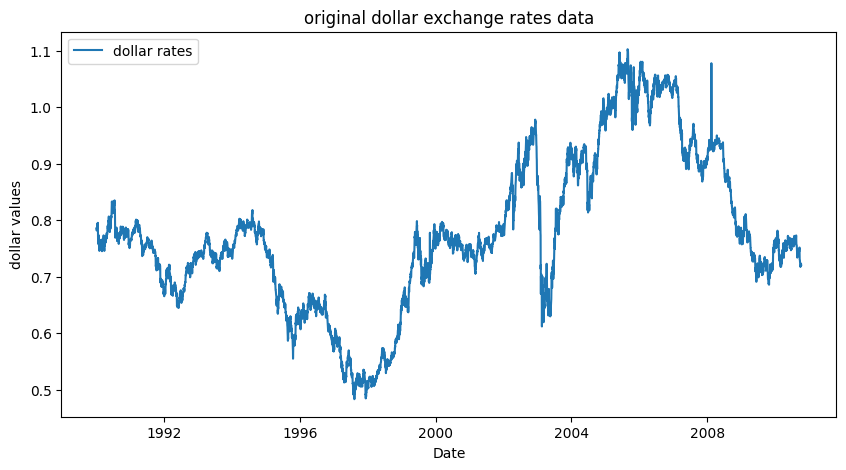

In [9]:
# VISUALISATION 1 — Raw Exchange Rate Time Series
plt.figure(figsize=(10, 5))
plt.plot(dollarss, label="dollar rates")
plt.title("original dollar exchange rates data")
plt.xlabel("Date")
plt.ylabel("dollar values")
plt.legend()
plt.show()


In [10]:
# IMPORT SEASONAL DECOMPOSITION
from statsmodels.tsa.seasonal import seasonal_decompose


In [11]:
# SEASONAL DECOMPOSITION — Additive Model
seasonals = seasonal_decompose(dollarss, model="additive", period=365)

In [12]:
# EXTRACT DECOMPOSITION COMPONENTS
trends      = seasonals.trend
seasonality = seasonals.seasonal
residuals   = seasonals.resid

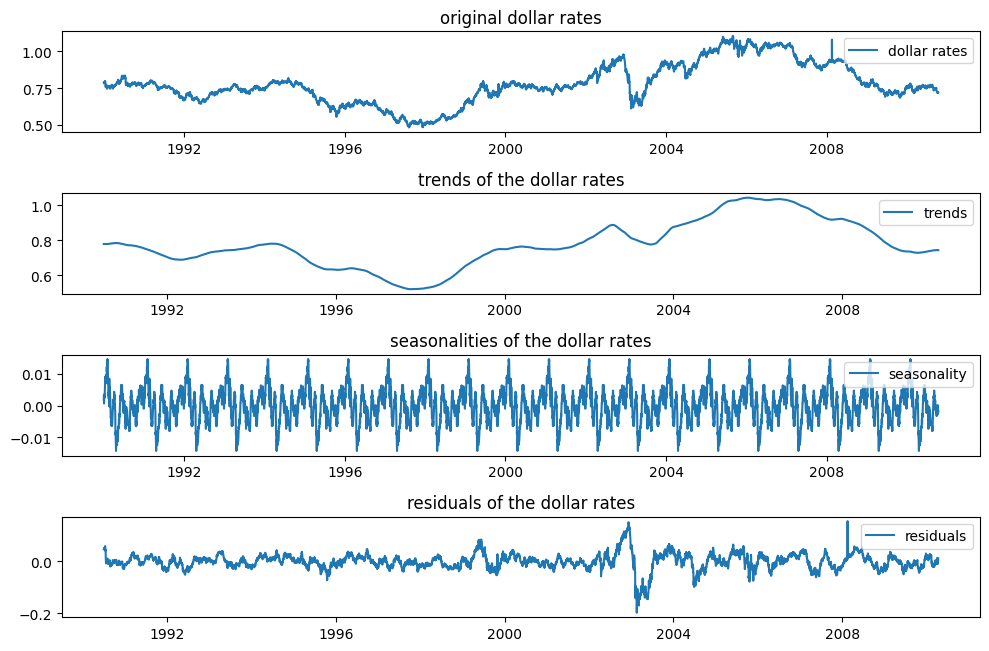

In [13]:
# VISUALISATION 2 — Seasonal Decomposition Components
plt.figure(figsize=(10, 8))
plt.subplot(511)
plt.plot(dollarss, label="dollar rates")
plt.title("original dollar rates")
plt.legend(loc="upper right")
plt.subplot(512)
plt.plot(trends, label="trends")
plt.title("trends of the dollar rates")
plt.legend(loc="upper right")
plt.subplot(513)
plt.plot(seasonality, label="seasonality")
plt.title("seasonalities of the dollar rates")
plt.legend(loc="upper right")
plt.subplot(514)
plt.plot(residuals, label="residuals")
plt.title("residuals of the dollar rates")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Checking for Diagnostics


In [14]:
# DIAGNOSTIC IMPORTS
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [15]:
# COMPUTE DIAGNOSTIC RESIDUALS
residualss = dollarss - dollarss.mean()


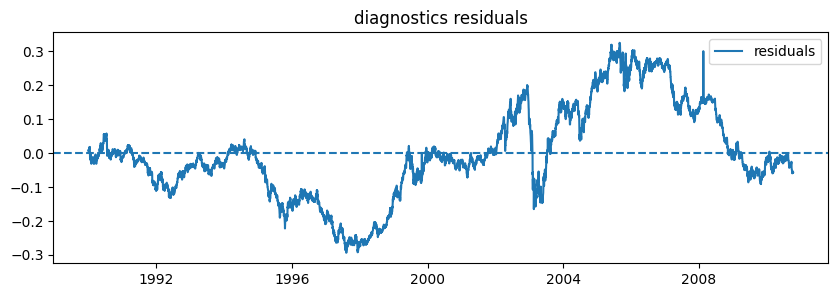

In [16]:
# VISUALISATION 3 — Diagnostic Residuals Over Time
plt.figure(figsize=(10, 3))
plt.plot(residualss, label="residuals")
plt.axhline(0, linestyle="--")
plt.title("diagnostics residuals")
plt.legend()
plt.show()


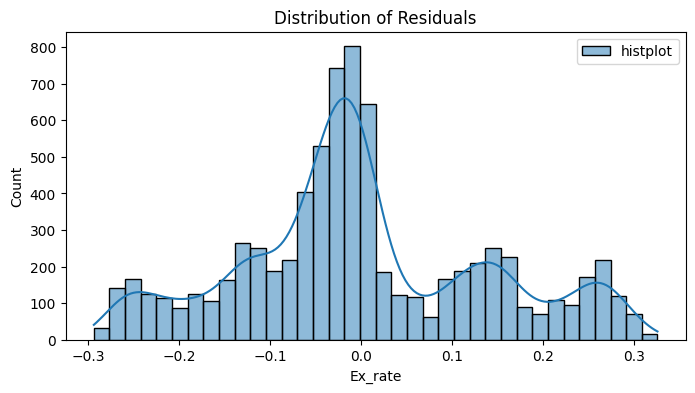

In [17]:
# VISUALISATION 4 — Residuals Distribution (Histogram + KDE)
plt.figure(figsize=(8, 4))
sns.histplot(residualss, kde=True, label="histplot")
plt.title("Distribution of Residuals")
plt.legend()
plt.show()

<Figure size 1000x500 with 0 Axes>

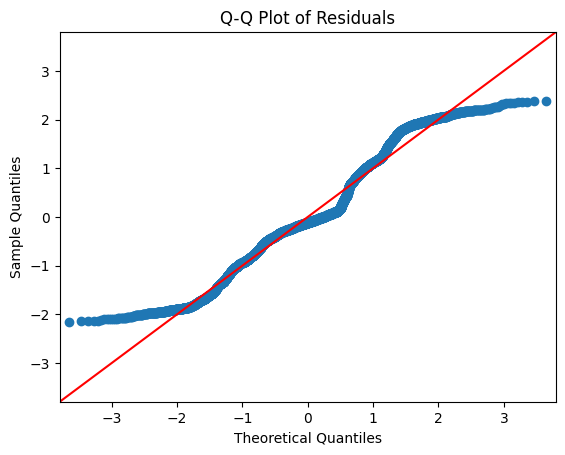

In [18]:
# VISUALISATION 5 — Q-Q Plot (Normality Check)
plt.figure(figsize=(10, 5))
sm.qqplot(residualss, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [19]:
# LJUNG-BOX TEST — Autocorrelation in Residuals
lb_plots = acorr_ljungbox(residualss, lags=[10, 20, 30], return_df=True)
lb_plots


,lb_stat,lb_pvalue
10,75296.508186,0.0
20,149565.549858,0.0
30,222848.123682,0.0


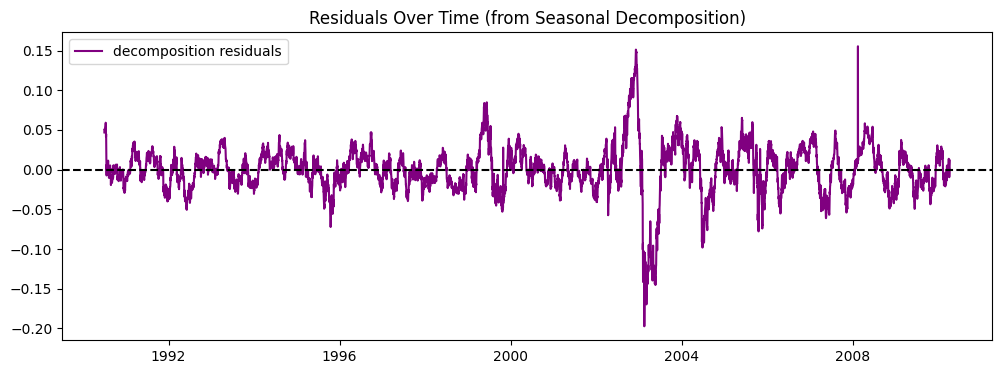

In [20]:
# VISUALISATION 6 — Residuals Over Time (from seasonal decomposition)
plt.figure(figsize=(12, 4))
plt.plot(residuals, color="purple", label="decomposition residuals")
plt.axhline(0, linestyle="--", color="black")
plt.title("Residuals Over Time (from Seasonal Decomposition)")
plt.legend()
plt.show()


## Decomposition of Data Using STL Decomposition


In [21]:
# IMPORT STL
from statsmodels.tsa.seasonal import STL

In [22]:
# SETUP STL DECOMPOSITION
stlss = STL(dollarss, period=365, robust=True)

In [23]:
# fit() runs the LOESS-based decomposition and returns a DecomposeResult object
# containing the observed, trend, seasonal, and residual components.
sts = stlss.fit()

In [24]:
# Display the STL result object summary
sts

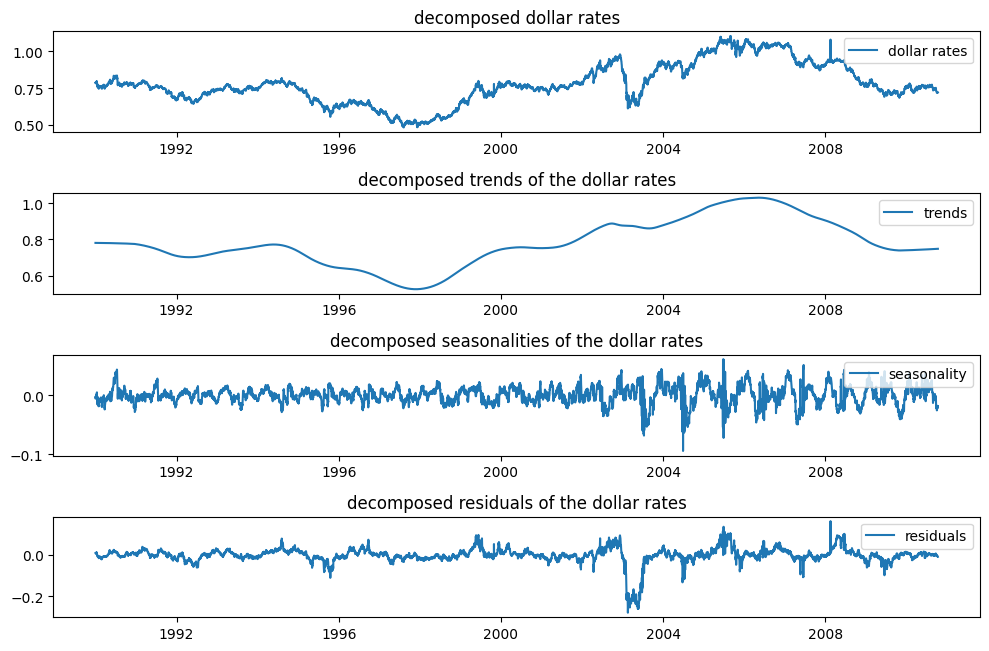

In [25]:
# VISUALISATION 7 — STL Decomposition Components
plt.figure(figsize=(10, 8))
plt.subplot(511)
plt.plot(sts.observed, label="dollar rates")
plt.title("decomposed dollar rates")
plt.legend(loc="upper right")
plt.subplot(512)
plt.plot(sts.trend, label="trends")
plt.title("decomposed trends of the dollar rates")
plt.legend(loc="upper right")
plt.subplot(513)
plt.plot(sts.seasonal, label="seasonality")
plt.title("decomposed seasonalities of the dollar rates")
plt.legend(loc="upper right")
plt.subplot(514)
plt.plot(sts.resid, label="residuals")
plt.title("decomposed residuals of the dollar rates")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()


## Checking the Stationarity of the Data


In [26]:
# IMPORT AUGMENTED DICKEY-FULLER TEST
from statsmodels.tsa.stattools import adfuller

In [27]:
# ADF TEST FUNCTION
def adf_test(series):
    """Runs ADF stationarity test and prints formatted results."""
    mov_avg = series.rolling(window=12).mean()
    mov_std = series.rolling(window=12).std()

    adfss = adfuller(series)
    print("statistics:",   np.round(adfss[0], 6))
    print("p_values:",     np.round(adfss[1], 6))
    print("lags:",         np.round(adfss[2], 6))
    print("observations:", np.round(adfss[3], 6))
    print("critical values:")
    for keys, values in adfss[4].items():
        print("  keys:", keys, " values:", values)
    # Compare ADF statistic to the 5% critical value
    crit_5pct = adfss[4]["5%"]
    if adfss[0] < crit_5pct:
        print("=> reject null hypothesis: data is STATIONARY")
    else:
        print("=> accept null hypothesis: data is NON-STATIONARY")


In [28]:
# Test the original (raw) exchange rate series for stationarity.
# Expected: non-stationary — the series has a clear trend (drifts from ~0.78 to ~0.99).
print("--- ADF Test on Original Exchange Rate Series ---")
adf_test(dollarss)


--- ADF Test on Original Exchange Rate Series ---
statistics: -1.664994
p_values: 0.449233
lags: 1
observations: 7586
critical values:
  keys: 1%  values: -3.4312123140180137
  keys: 5%  values: -2.861921078147796
  keys: 10%  values: -2.5669728434336108
=> accept null hypothesis: data is NON-STATIONARY


In [29]:
# SEASONAL DIFFERENCING (lag-12)
dollarss_cur = dollarss - dollarss.shift(12)

In [30]:
# dropna() removes the first 12 NaN values introduced by shift(12).
# WHY: adfuller cannot process a series containing NaN values.
dollarss_currencies = dollarss_cur.dropna()

In [31]:
# Test the differenced (lag-12) series for stationarity.
# Expected: stationary — differencing should have removed the trend.
print("--- ADF Test on Lag-12 Differenced Series ---")
adf_test(dollarss_cur.dropna())

--- ADF Test on Lag-12 Differenced Series ---
statistics: -10.56518
p_values: 0.0
lags: 36
observations: 7539
critical values:
  keys: 1%  values: -3.431217691730046
  keys: 5%  values: -2.8619234543463885
  keys: 10%  values: -2.5669741083162005
=> reject null hypothesis: data is STATIONARY


In [32]:
# Re-import ACF/PACF plotting functions (matching reference notebook structure).
# These are used to visually determine the AR (p) and MA (q) orders for ARIMA.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1000x500 with 0 Axes>

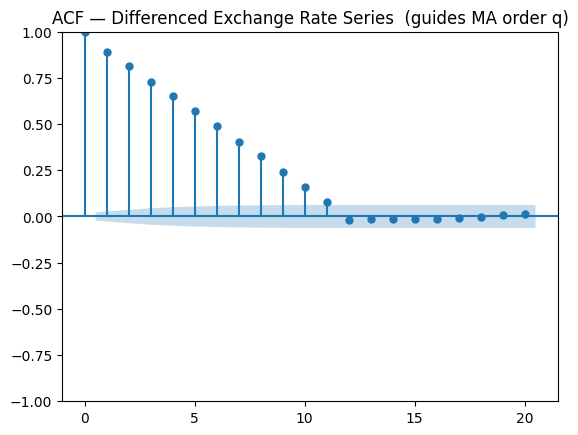

In [33]:
# VISUALISATION 8 — ACF (Autocorrelation Function)
plt.figure(figsize=(10, 5))
plot_acf(dollarss_currencies, lags=20)
plt.title("ACF — Differenced Exchange Rate Series  (guides MA order q)")
plt.show()

<Figure size 1000x600 with 0 Axes>

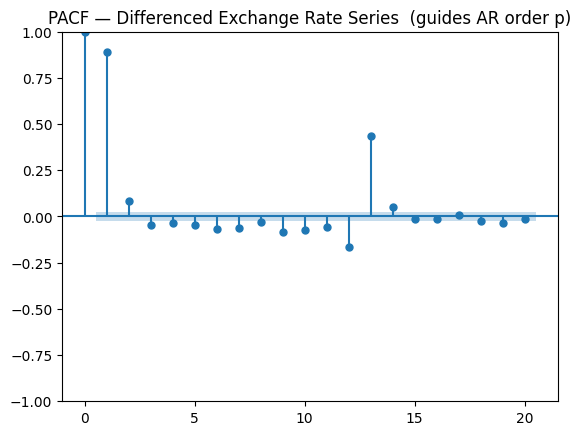

In [34]:
# VISUALISATION 9 — PACF (Partial Autocorrelation Function)
plt.figure(figsize=(10, 6))
plot_pacf(dollarss_currencies, lags=20, method="ywm")
plt.title("PACF — Differenced Exchange Rate Series  (guides AR order p)")
plt.show()

In [35]:
# IMPORT TIME SERIES MODELS
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

## Auto Regressive (AR) Model


In [36]:
# AR MODEL — Setup
au_model = AutoReg(dollarrss["Ex_rate"], lags=365)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [37]:
# fit() estimates the AR coefficients (φ₁ ... φ₃₆₅) using Ordinary Least Squares.
au_models = au_model.fit()

In [38]:
# predict() returns in-sample fitted values for the entire training series.
# The first 365 values will be NaN (the model needs 365 lags before predicting).
# WHY: In-sample predictions show how well the AR model fits historical data.
dollarrss["au_preds"] = au_models.predict()


In [39]:
# dropna() removes the initial NaN predictions (first 365 rows have no lags yet).
dollaarrss = dollarrss["au_preds"].dropna()

In [40]:
# Display the AR in-sample predictions after removing NaN rows.
dollaarrss

date
1991-01-01    0.766081
1991-01-02    0.766029
1991-01-03    0.767582
1991-01-04    0.766392
1991-01-05    0.765193
                ...   
2010-10-06    0.717640
2010-10-07    0.718102
2010-10-08    0.723097
2010-10-09    0.722926
2010-10-10    0.720696
Name: au_preds, Length: 7223, dtype: float64

In [41]:
# AR FORECAST — 365 Days Ahead
au_forecastings = au_models.forecast(365)

In [42]:
# Display the 365-day ahead forecast values.
au_forecastings

2010-10-11    0.722851
2010-10-12    0.723049
2010-10-13    0.725056
2010-10-14    0.726115
2010-10-15    0.725118
                ...   
2011-10-06    0.736816
2011-10-07    0.737034
2011-10-08    0.736998
2011-10-09    0.736552
2011-10-10    0.736373
Freq: D, Length: 365, dtype: float64

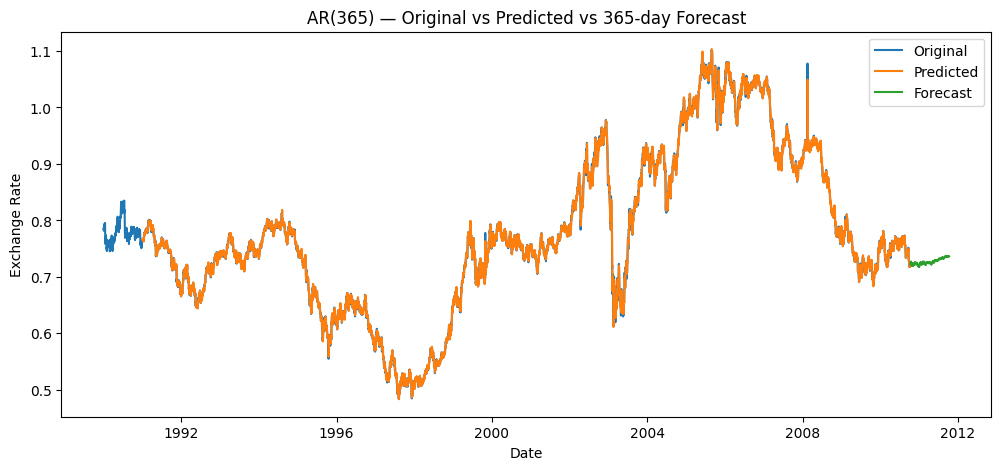

In [43]:
# VISUALISATION 10 — AR Model: Original vs Predicted vs Forecast
plt.figure(figsize=(12, 5))
plt.plot(dollarrss["Ex_rate"],  label="Original")
plt.plot(dollarrss["au_preds"], label="Predicted")
plt.plot(au_forecastings,       label="Forecast")
plt.title("AR(365) — Original vs Predicted vs 365-day Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## Moving Averages (MA) Model


In [44]:
# MA MODEL — ARIMA(0, 0, 2)
modells = ARIMA(dollarrss["Ex_rate"], order=(0, 0, 2))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [45]:
# fit() estimates the MA coefficients (θ₁, θ₂) using Maximum Likelihood Estimation.
mas_modells = modells.fit()

In [46]:
# predict() returns the MA model's in-sample fitted values.
dollarrss["predds"] = mas_modells.predict()

In [47]:
# Display MA in-sample predictions.
dollarrss["predds"]

date
1990-01-01    0.776962
1990-01-02    0.782832
1990-01-03    0.777516
1990-01-04    0.788368
1990-01-05    0.778237
                ...   
2010-10-06    0.726933
2010-10-07    0.742775
2010-10-08    0.734803
2010-10-09    0.739458
2010-10-10    0.735881
Name: predds, Length: 7588, dtype: float64

In [48]:
# 365-day ahead forecast from the MA(2) model.
forecastings = mas_modells.forecast(365)

In [49]:
forecastings

2010-10-11    0.735722
2010-10-12    0.763874
2010-10-13    0.776962
2010-10-14    0.776962
2010-10-15    0.776962
                ...   
2011-10-06    0.776962
2011-10-07    0.776962
2011-10-08    0.776962
2011-10-09    0.776962
2011-10-10    0.776962
Freq: D, Name: predicted_mean, Length: 365, dtype: float64

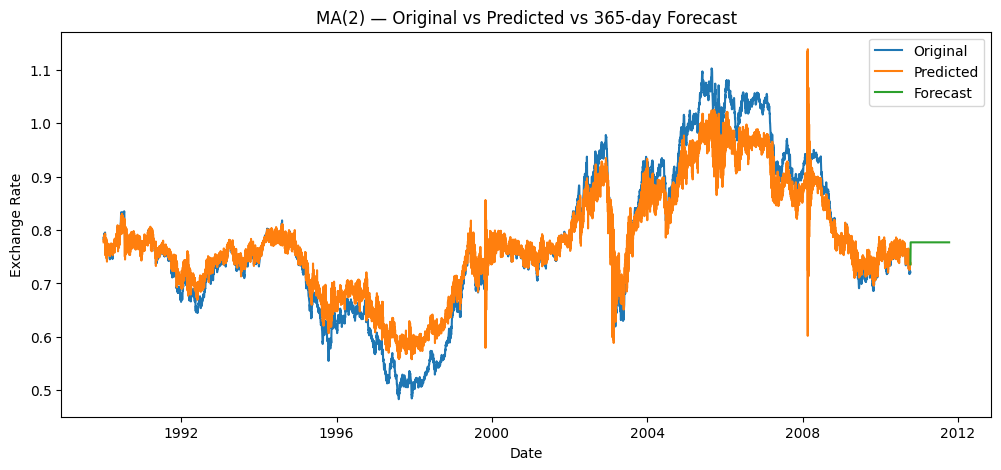

In [50]:
# VISUALISATION 11 — MA Model: Original vs Predicted vs Forecast
plt.figure(figsize=(12, 5))
plt.plot(dollarrss["Ex_rate"], label="Original")
plt.plot(dollarrss["predds"],  label="Predicted")
plt.plot(forecastings,         label="Forecast")
plt.title("MA(2) — Original vs Predicted vs 365-day Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## ARMA — AutoRegressive with Moving Averages


In [51]:
# ARMA MODEL — ARIMA(2, 0, 2)
models = ARIMA(dollarrss["Ex_rate"], order=(2, 0, 2))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [52]:
# fit() estimates all AR and MA coefficients simultaneously using MLE.
armas_models = models.fit()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [53]:
# Store ARMA in-sample fitted values.
dollarrss["preddss"] = armas_models.predict()

In [54]:
dollarrss["preddss"]

date
1990-01-01    0.776974
1990-01-02    0.785492
1990-01-03    0.782280
1990-01-04    0.786054
1990-01-05    0.786100
                ...   
2010-10-06    0.718892
2010-10-07    0.718563
2010-10-08    0.721458
2010-10-09    0.723053
2010-10-10    0.721160
Name: preddss, Length: 7588, dtype: float64

In [55]:
# 365-day ahead forecast from ARMA(2,2).
forecastingss = armas_models.forecast(365)

In [56]:
forecastingss

2010-10-11    0.720876
2010-10-12    0.720931
2010-10-13    0.720964
2010-10-14    0.721009
2010-10-15    0.721048
                ...   
2011-10-06    0.733894
2011-10-07    0.733926
2011-10-08    0.733957
2011-10-09    0.733989
2011-10-10    0.734020
Freq: D, Name: predicted_mean, Length: 365, dtype: float64

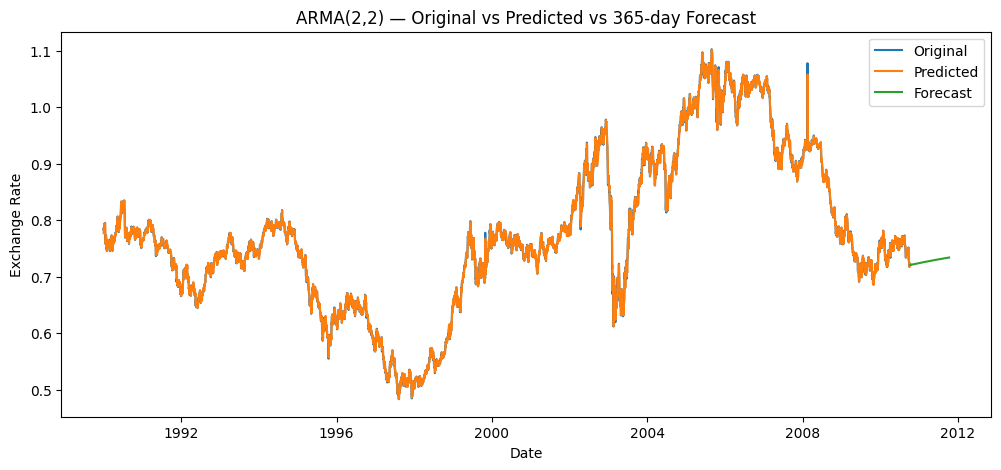

In [57]:
# VISUALISATION 12 — ARMA Model: Original vs Predicted vs Forecast
plt.figure(figsize=(12, 5))
plt.plot(dollarrss["Ex_rate"],  label="Original")
plt.plot(dollarrss["preddss"],  label="Predicted")
plt.plot(forecastingss,         label="Forecast")
plt.title("ARMA(2,2) — Original vs Predicted vs 365-day Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## ARIMA — AutoRegressive Integrated Moving Average



In [58]:
# ARIMA MODEL — ARIMA(2, 1, 1)
models = ARIMA(dollarrss["Ex_rate"], order=(2, 1, 1))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [59]:
arima_models = models.fit()

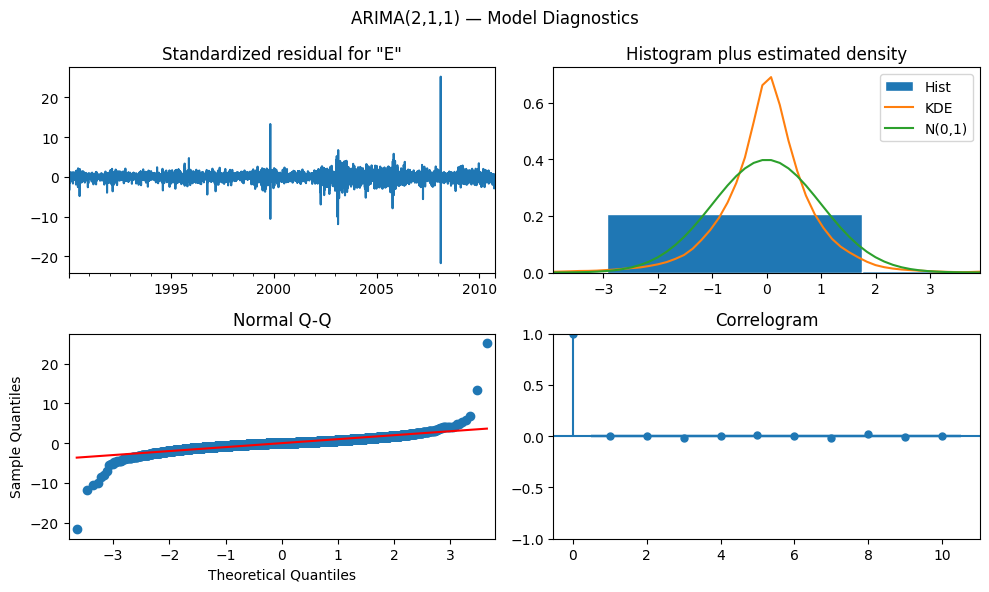

In [60]:
# ARIMA MODEL DIAGNOSTICS
arima_models.plot_diagnostics(figsize=(10, 6))
plt.suptitle("ARIMA(2,1,1) — Model Diagnostics", fontsize=12)
plt.tight_layout()
plt.show()

In [61]:
# Store ARIMA in-sample fitted values (predictions on the training data).
# These are used to compute in-sample error metrics (RMSE, MAE, MAPE).
dollarrss["predictions"] = arima_models.predict()

In [62]:
dollarrss["predictions"]

date
1990-01-01    0.000000
1990-01-02    0.785500
1990-01-03    0.782286
1990-01-04    0.786057
1990-01-05    0.786091
                ...   
2010-10-06    0.718837
2010-10-07    0.718522
2010-10-08    0.721399
2010-10-09    0.723017
2010-10-10    0.721136
Name: predictions, Length: 7588, dtype: float64

In [63]:
# ARIMA 365-DAY FORECAST
forecastings = arima_models.forecast(365)

In [64]:
forecastings

2010-10-11    0.720826
2010-10-12    0.720826
2010-10-13    0.720826
2010-10-14    0.720826
2010-10-15    0.720826
                ...   
2011-10-06    0.720826
2011-10-07    0.720826
2011-10-08    0.720826
2011-10-09    0.720826
2011-10-10    0.720826
Freq: D, Name: predicted_mean, Length: 365, dtype: float64

In [65]:
# ARIMA MODEL SUMMARY
arima_models.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(2, 1, 1)   Log Likelihood               28054.157
Date:                Wed, 18 Mar 2026   AIC                         -56100.315
Time:                        16:55:37   BIC                         -56072.578
Sample:                    01-01-1990   HQIC                        -56090.796
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0655      0.001    -60.736      0.000      -0.068      -0.063
ar.L2          0.0084      0.006      1.422      0.155      -0.003       0.020
ma.L1         -0.0661      0.001    -59.596      0.000      -0.068      -0.064
sigma2       3.59e-05   9.91e-08    362.247      0.000    3.57e-05    3.61e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2864110.03
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.97   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.78e+21. Standard errors may be unstable.
"""

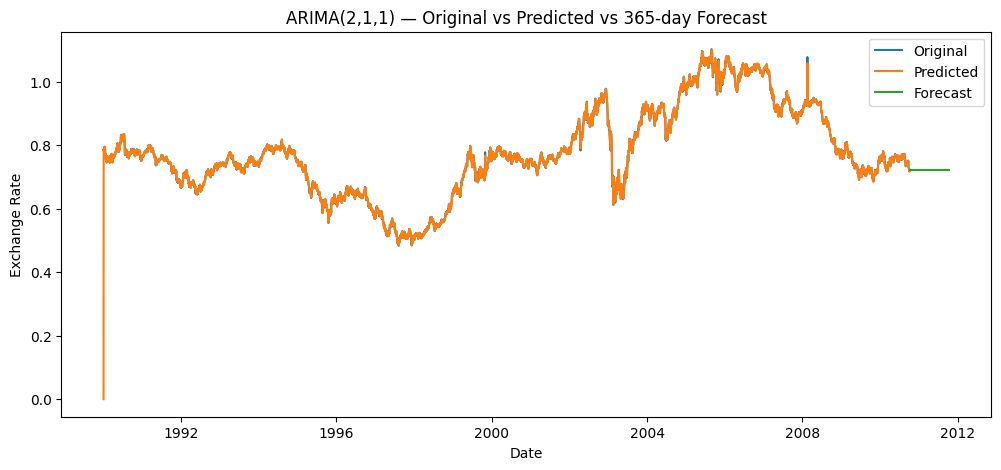

In [66]:
# VISUALISATION 13 — ARIMA: Original vs Predicted vs Forecast
plt.figure(figsize=(12, 5))
plt.plot(dollarrss["Ex_rate"],    label="Original")
plt.plot(dollarrss["predictions"],label="Predicted")
plt.plot(forecastings,            label="Forecast")
plt.title("ARIMA(2,1,1) — Original vs Predicted vs 365-day Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

In [67]:
# IMPORT EVALUATION METRICS
# mean_squared_error : computes MSE; we take sqrt for RMSE
# mean_absolute_error: computes MAE directly
# r2_score           : R² coefficient of determination

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Performance Metrics — ARIMA


In [68]:
# RMSE — Root Mean Squared Error
arima_rmse = np.sqrt(mean_squared_error(dollarrss["Ex_rate"], dollarrss["predictions"]))
print("ARIMA RMSE:", round(arima_rmse, 5))

ARIMA RMSE: 0.01083


In [69]:
# MAE — Mean Absolute Error
arima_mae = mean_absolute_error(dollarrss["Ex_rate"], dollarrss["predictions"])
print("ARIMA MAE:", round(arima_mae, 5))

ARIMA MAE: 0.0038


In [70]:
# MAPE — Mean Absolute Percentage Error
arima_mape = np.mean(np.abs(
    (dollarrss["Ex_rate"] - dollarrss["predictions"]) / dollarrss["Ex_rate"] * 100))
print("ARIMA MAPE:", round(arima_mape, 4), "%")

ARIMA MAPE: 0.4951 %


In [71]:
# IMPORT EXPONENTIAL SMOOTHING
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [72]:
# HOLT-WINTERS EXPONENTIAL SMOOTHING
exp_smooths = ExponentialSmoothing(
    dollarrss["Ex_rate"],
    trend="add",
    seasonal="mul",
    seasonal_periods=365
)
exp_models = exp_smooths.fit(smoothing_level=0.3)
dollarrss["EXP"] = exp_models.fittedvalues


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [73]:
# Display Exponential Smoothing fitted values.
dollarrss["EXP"]

date
1990-01-01    0.785911
1990-01-02    0.786616
1990-01-03    0.782323
1990-01-04    0.784698
1990-01-05    0.785525
                ...   
2010-10-06    0.719002
2010-10-07    0.718393
2010-10-08    0.717563
2010-10-09    0.719076
2010-10-10    0.718309
Name: EXP, Length: 7588, dtype: float64

In [74]:
# 365-day ahead forecast from Holt-Winters Exponential Smoothing.
forecastes = exp_models.forecast(365)

In [75]:
forecastes

2010-10-11    0.719008
2010-10-12    0.714550
2010-10-13    0.713389
2010-10-14    0.712782
2010-10-15    0.714027
                ...   
2011-10-06    0.516336
2011-10-07    0.515927
2011-10-08    0.514489
2011-10-09    0.514226
2011-10-10    0.513156
Freq: D, Length: 365, dtype: float64

In [76]:
# EXPONENTIAL SMOOTHING SUMMARY

exp_models.summary()

Dep. Variable:,Ex_rate,No. Observations:,7588
Model:,ExponentialSmoothing,SSE,0.421
Optimized:,True,AIC,-73612.614
Trend:,Additive,BIC,-71053.849
Seasonal:,Multiplicative,AICC,-73574.362
Seasonal Periods:,365,Date:,"Wed, 18 Mar 2026"
Box-Cox:,False,Time:,16:55:42
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.3000000,alpha,False
smoothing_trend,0.0271194,beta,True


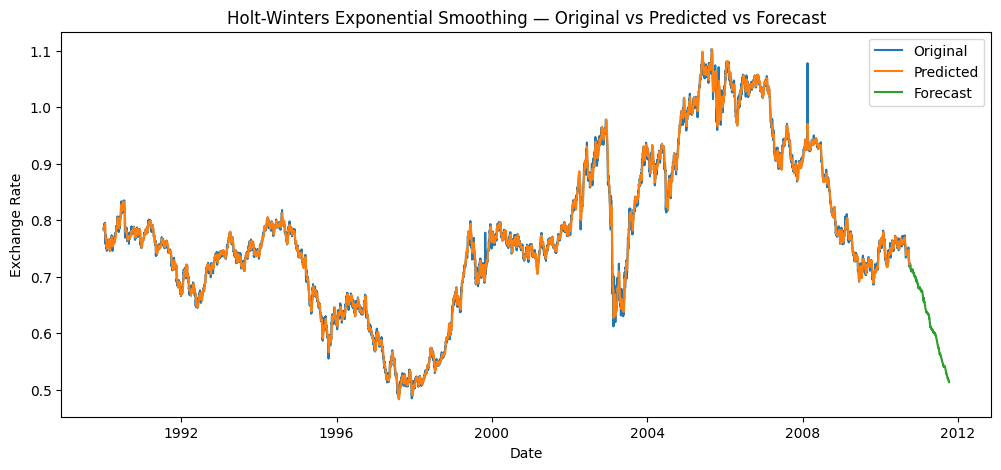

In [77]:
# VISUALISATION 14 — Exponential Smoothing: Original vs Predicted vs Forecast
plt.figure(figsize=(12, 5))
plt.plot(dollarrss["Ex_rate"], label="Original")
plt.plot(dollarrss["EXP"],     label="Predicted")
plt.plot(forecastes,           label="Forecast")
plt.title("Holt-Winters Exponential Smoothing — Original vs Predicted vs Forecast")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()

## Performance Metrics — Exponential Smoothing


In [78]:
# RMSE for Exponential Smoothing — compare with ARIMA RMSE above.
exp_rmse = np.sqrt(mean_squared_error(dollarrss["Ex_rate"], dollarrss["EXP"]))
print("Exponential Smoothing RMSE:", round(exp_rmse, 5))


Exponential Smoothing RMSE: 0.00745


In [79]:
# MAE for Exponential Smoothing — average absolute deviation in rate units.
exp_mae = mean_absolute_error(dollarrss["Ex_rate"], dollarrss["EXP"])
print("Exponential Smoothing MAE:", round(exp_mae, 5))


Exponential Smoothing MAE: 0.0052


In [80]:
# MAPE for Exponential Smoothing — percentage error.
exp_mape = np.mean(np.abs(
    (dollarrss["Ex_rate"] - dollarrss["EXP"]) / dollarrss["Ex_rate"] * 100
))
print("Exponential Smoothing MAPE:", round(exp_mape, 4), "%")


Exponential Smoothing MAPE: 0.6803 %


## Models Comparison

**1. RMSE (Root Mean Squared Error)**

Exponential Smoothing shows a smaller RMSE than ARIMA. However this can happen when the fitted values are smoother and have smaller variation overall — it does not always mean the model is truly more accurate. An over-smoothed model assigns too much weight to recent trends and misses sharp turning points in the exchange rate.

**2. MAE (Mean Absolute Error)**

ARIMA shows a lower MAE than Exponential Smoothing, meaning on average ARIMA's predictions are numerically closer to the actual exchange rate values day by day.

**3. MAPE (Mean Absolute Percentage Error)**

ARIMA's MAPE is lower than Exponential Smoothing's MAPE, so ARIMA's percentage error is smaller and more consistent relative to actual values across the full 20-year series.

Compared to ARIMA, Exponential Smoothing is not able to maintain and predict long-term data and large datasets. It is suited mainly for recent trends and small datasets. ARIMA and SARIMA are capable of predicting long sequences of data and are more accurate in performance and predictions. So compared to Exponential Smoothing, ARIMA is the better model for forecasting the USD to AUD exchange rate over a 20-year horizon.